# Smart City IDS Dataset Feature Engineering

This document takes raw PCAP traffic logs and transforms them into a structured machine learning dataset. These raw PCAP traffic logs have been collected from an isolated VirtualBox network lab. The machine learning dataset consists of normal HTTP traffic, as well as SYN flood, UDP flood, and HTTP flood traffic.

The features have been extracted using Scapy and pandas libraries from the PCAP files. The resulting output is a cleaned CSV file consisting of 100,000 rows of packet data records ready to be used for machine learning.

In [ ]:
!pip install scapy pandas

In [ ]:
import os

pcap_files = [
    "normal_traffic_gen_100k.pcap",
    "syn_flood_hping3_atk_gen_100k.pcap",
    "udp_flood_nping_atk_gen_100k.pcap",
    "http_flood_curl_atk_gen_100k.pcap"
]

for file in pcap_files:
    print(file, "exists:", os.path.exists(file))

normal_traffic_gen_100k.pcap exists: True
syn_flood_hping3_atk_gen_100k.pcap exists: True
udp_flood_nping_atk_gen_100k.pcap exists: True
http_flood_curl_atk_gen_100k.pcap exists: True


# Two options to add the files

1.   Upload the files
2.   Give access to google drive



Option 1

In [ ]:
from google.colab import files

uploaded = files.upload()

## Feature Extraction and Engineering

However, the uploaded PCAP files are uncooked data sets that will not work for machine learning tasks. Therefore, Scapy will be used to open each of the uploaded PCAP files and extract features at the packet level and flow level.

The chosen features will include source/destination IP addresses, source/destination ports, protocol type, packet sizes, payload sizes, TCP flags, HTTP flag, number of packets, total amount of bytes sent, time duration, number of packets per second, total bytes per second, and HTTP/TCP/UDP packet counts.

In [ ]:
from scapy.all import rdpcap, IP, TCP, UDP, Raw, ARP
import pandas as pd
from collections import defaultdict
import os

pcap_labels = {
    "normal_traffic_gen_100k.pcap": "normal",
    "syn_flood_hping3_atk_gen_100k.pcap": "syn_flood",
    "udp_flood_nping_atk_gen_100k.pcap": "udp_flood",
    "http_flood_curl_atk_gen_100k.pcap": "http_flood"
}

packet_rows = []

flow_stats = defaultdict(lambda: {
    "packet_count": 0,
    "total_bytes": 0,
    "sizes": [],
    "start_time": None,
    "end_time": None,
    "syn_count": 0,
    "ack_count": 0,
    "rst_count": 0,
    "fin_count": 0,
    "udp_count": 0,
    "http_count": 0
})

def get_protocol(pkt):
    if TCP in pkt:
        return "TCP"
    if UDP in pkt:
        return "UDP"
    if ARP in pkt:
        return "ARP"
    return "OTHER"

def get_ips(pkt):
    if IP in pkt:
        return pkt[IP].src, pkt[IP].dst
    if ARP in pkt:
        return pkt[ARP].psrc, pkt[ARP].pdst
    return "0.0.0.0", "0.0.0.0"

def get_ports(pkt):
    if TCP in pkt:
        return pkt[TCP].sport, pkt[TCP].dport
    if UDP in pkt:
        return pkt[UDP].sport, pkt[UDP].dport
    return 0, 0

def get_tcp_flags(pkt):
    if TCP in pkt:
        return int(pkt[TCP].flags)
    return 0

def get_payload_size(pkt):
    if Raw in pkt:
        return len(pkt[Raw].load)
    return 0

def get_flow_key(pkt, label):
    src_ip, dst_ip = get_ips(pkt)
    src_port, dst_port = get_ports(pkt)
    protocol = get_protocol(pkt)
    return (label, src_ip, dst_ip, src_port, dst_port, protocol)

for pcap_file, label in pcap_labels.items():
    if not os.path.exists(pcap_file):
        print(f"Missing file: {pcap_file}")
        continue

    print(f"Reading {pcap_file} as {label}")
    packets = rdpcap(pcap_file)

    for pkt in packets:
        pkt_time = float(pkt.time)
        pkt_len = len(pkt)

        src_ip, dst_ip = get_ips(pkt)
        src_port, dst_port = get_ports(pkt)
        protocol = get_protocol(pkt)
        tcp_flags = get_tcp_flags(pkt)
        payload_size = get_payload_size(pkt)
        flow_key = get_flow_key(pkt, label)

        is_http = 0
        if TCP in pkt and (pkt[TCP].sport == 80 or pkt[TCP].dport == 80):
            is_http = 1

        stats = flow_stats[flow_key]
        stats["packet_count"] += 1
        stats["total_bytes"] += pkt_len
        stats["sizes"].append(pkt_len)

        if stats["start_time"] is None:
            stats["start_time"] = pkt_time
        stats["end_time"] = pkt_time

        if TCP in pkt:
            flags = pkt[TCP].flags

            if flags & 0x02:
                stats["syn_count"] += 1
            if flags & 0x10:
                stats["ack_count"] += 1
            if flags & 0x04:
                stats["rst_count"] += 1
            if flags & 0x01:
                stats["fin_count"] += 1

            if pkt[TCP].sport == 80 or pkt[TCP].dport == 80:
                stats["http_count"] += 1

        if UDP in pkt:
            stats["udp_count"] += 1

        packet_rows.append({
            "timestamp": pkt_time,
            "src_ip": src_ip,
            "dst_ip": dst_ip,
            "src_port": src_port,
            "dst_port": dst_port,
            "protocol": protocol,
            "packet_length": pkt_len,
            "payload_size": payload_size,
            "tcp_flags": tcp_flags,
            "is_http": is_http,
            "flow_key": flow_key,
            "label": label
        })

final_rows = []

for row in packet_rows:
    stats = flow_stats[row["flow_key"]]

    duration = stats["end_time"] - stats["start_time"]
    if duration <= 0:
        duration = 0.000001

    packet_count = stats["packet_count"]
    total_bytes = stats["total_bytes"]

    final_rows.append({
        "timestamp": row["timestamp"],
        "src_ip": row["src_ip"],
        "dst_ip": row["dst_ip"],
        "src_port": row["src_port"],
        "dst_port": row["dst_port"],
        "protocol": row["protocol"],
        "packet_length": row["packet_length"],
        "payload_size": row["payload_size"],
        "tcp_flags": row["tcp_flags"],
        "is_http": row["is_http"],
        "flow_packet_count": packet_count,
        "flow_total_bytes": total_bytes,
        "flow_duration": duration,
        "flow_avg_packet_size": total_bytes / packet_count,
        "flow_min_packet_size": min(stats["sizes"]),
        "flow_max_packet_size": max(stats["sizes"]),
        "flow_packet_rate": packet_count / duration,
        "flow_byte_rate": total_bytes / duration,
        "flow_syn_count": stats["syn_count"],
        "flow_ack_count": stats["ack_count"],
        "flow_rst_count": stats["rst_count"],
        "flow_fin_count": stats["fin_count"],
        "flow_udp_count": stats["udp_count"],
        "flow_http_count": stats["http_count"],
        "label": row["label"]
    })

df = pd.DataFrame(final_rows)
df = df.fillna(0)

# Keep exactly 1000 rows
#df = df.head(1000)

df.to_csv("smartcity_clean_dataset_100k.csv", index=False)

print("Saved smartcity_clean_dataset_100k.csv")
print("Dataset shape:", df.shape)
print("\nLabel counts:")
print(df["label"].value_counts())
print("\nProtocol counts:")
print(df["protocol"].value_counts())

Reading normal_traffic_gen_100k.pcap as normal
Reading syn_flood_hping3_atk_gen_100k.pcap as syn_flood
Reading udp_flood_nping_atk_gen_100k.pcap as udp_flood
Reading http_flood_curl_atk_gen_100k.pcap as http_flood
Saved smartcity_clean_dataset_100k.csv
Dataset shape: (100000, 25)

Label counts:
label
normal        50000
syn_flood     17000
udp_flood     17000
http_flood    16000
Name: count, dtype: int64

Protocol counts:
protocol
TCP      82998
UDP      16624
OTHER      340
ARP         38
Name: count, dtype: int64


In [ ]:
df["label"].value_counts()

,count
label,
normal,50000
syn_flood,17000
udp_flood,17000
http_flood,16000


In [ ]:
# Step 1: Save the detailed original label into attack_type
df["attack_type"] = df["label"]

# Step 2: Convert label into binary normal/attack
df["label"] = df["attack_type"].apply(lambda x: "normal" if x == "normal" else "attack")

# Step 3: Save the corrected dataset
df.to_csv("smartcity_clean_dataset_100k.csv", index=False)

# Step 4: Check results
print("Dataset shape:", df.shape)

print("\nBinary label counts:")
print(df["label"].value_counts())

print("\nAttack type counts:")
print(df["attack_type"].value_counts())

Dataset shape: (100000, 26)

Binary label counts:
label
normal    50000
attack    50000
Name: count, dtype: int64

Attack type counts:
attack_type
normal        50000
syn_flood     17000
udp_flood     17000
http_flood    16000
Name: count, dtype: int64


In [ ]:
df.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,packet_length,payload_size,tcp_flags,is_http,...,flow_packet_rate,flow_byte_rate,flow_syn_count,flow_ack_count,flow_rst_count,flow_fin_count,flow_udp_count,flow_http_count,label,attack_type
0,1.779042e+09,192.168.82.30,192.168.82.20,49673,80,TCP,66,0,2,1,...,39.412001,2971.664896,1,4,0,1,0,5,normal,normal
1,1.779042e+09,192.168.82.20,192.168.82.30,80,49673,TCP,66,0,18,1,...,31.716583,9245.383912,1,4,0,1,0,4,normal,normal
2,1.779042e+09,192.168.82.30,192.168.82.20,49673,80,TCP,60,0,16,1,...,39.412001,2971.664896,1,4,0,1,0,5,normal,normal
3,1.779042e+09,192.168.82.30,192.168.82.20,49673,80,TCP,131,77,24,1,...,39.412001,2971.664896,1,4,0,1,0,5,normal,normal
4,1.779042e+09,192.168.82.20,192.168.82.30,80,49673,TCP,60,0,16,1,...,31.716583,9245.383912,1,4,0,1,0,4,normal,normal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   timestamp             100000 non-null  float64
 1   src_ip                100000 non-null  object 
 2   dst_ip                100000 non-null  object 
 3   src_port              100000 non-null  int64  
 4   dst_port              100000 non-null  int64  
 5   protocol              100000 non-null  object 
 6   packet_length         100000 non-null  int64  
 7   payload_size          100000 non-null  int64  
 8   tcp_flags             100000 non-null  int64  
 9   is_http               100000 non-null  int64  
 10  flow_packet_count     100000 non-null  int64  
 11  flow_total_bytes      100000 non-null  int64  
 12  flow_duration         100000 non-null  float64
 13  flow_avg_packet_size  100000 non-null  float64
 14  flow_min_packet_size  100000 non-null  int64  
 15  f

In [ ]:
df["label"].value_counts()

,count
label,
normal,50000
attack,50000


In [ ]:
import os

os.path.exists("smartcity_clean_dataset_100k.csv")

True

In [ ]:
df.shape

(100000, 26)

In [ ]:
df["label"].value_counts()

,count
label,
normal,50000
attack,50000


In [ ]:
from scapy.all import rdpcap

pcap_files = [
    "normal_traffic_gen_100k.pcap",
    "syn_flood_hping3_atk_gen_100k.pcap",
    "udp_flood_nping_atk_gen_100k.pcap",
    "http_flood_curl_atk_gen_100k.pcap"
]

for file in pcap_files:
    packets = rdpcap(file)
    print(file, len(packets))

In [ ]:
df["protocol"].value_counts()

,count
protocol,
TCP,82998
UDP,16624
OTHER,340
ARP,38


In [ ]:
from google.colab import files
files.download("smartcity_clean_dataset_100k.csv")

# Training ML Models & Evaluation

Supervised machine learning models will be built here to classify traffic into either **normal** or **attack** from the cleaned 100k data set.

The target in machine learning is the `label` column. The `attack_type` column will only serve as an analysis tool but not in the features list as it shows what kind of traffic it is.

In [ ]:
import pandas as pd

# Load the cleaned dataset generated from the 100k PCAP captures
df = pd.read_csv("smartcity_clean_dataset_100k.csv")

print("Dataset shape:", df.shape)
print("Binary label distribution:")
print(df["label"].value_counts())
print("Detailed attack type distribution:")
print(df["attack_type"].value_counts())
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.head()

Dataset shape: (100000, 26)
Binary label distribution:
label
normal    50000
attack    50000
Name: count, dtype: int64
Detailed attack type distribution:
attack_type
normal        50000
syn_flood     17000
udp_flood     17000
http_flood    16000
Name: count, dtype: int64
Missing values: 0
Duplicate rows: 24


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,packet_length,payload_size,tcp_flags,is_http,...,flow_packet_rate,flow_byte_rate,flow_syn_count,flow_ack_count,flow_rst_count,flow_fin_count,flow_udp_count,flow_http_count,label,attack_type
0,1.779042e+09,192.168.82.30,192.168.82.20,49673,80,TCP,66,0,2,1,...,39.412001,2971.664896,1,4,0,1,0,5,normal,normal
1,1.779042e+09,192.168.82.20,192.168.82.30,80,49673,TCP,66,0,18,1,...,31.716583,9245.383912,1,4,0,1,0,4,normal,normal
2,1.779042e+09,192.168.82.30,192.168.82.20,49673,80,TCP,60,0,16,1,...,39.412001,2971.664896,1,4,0,1,0,5,normal,normal
3,1.779042e+09,192.168.82.30,192.168.82.20,49673,80,TCP,131,77,24,1,...,39.412001,2971.664896,1,4,0,1,0,5,normal,normal
4,1.779042e+09,192.168.82.20,192.168.82.30,80,49673,TCP,60,0,16,1,...,31.716583,9245.383912,1,4,0,1,0,4,normal,normal


## Feature Selection Strategy

Even though there are 26 columns that have been engineered by me for this dataset, only some selected packet level features have been included while building the model. This will minimize the risk of overfitting, and the inclusion of unique features like `attack_type` and IPs would introduce data leakage.

Selected features:

- `src_port`: source-side communication port
- `dst_port`: destination service port, such as HTTP port 80
- `protocol`: packet protocol such as TCP, UDP, or ARP
- `packet_length`: total packet size
- `payload_size`: size of the actual packet payload

The target column is `label`, which contains only `normal` and `attack`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
import pandas as pd

# Selected realistic packet-level features from the CSV.
# These are used to avoid data leakage and reduce unrealistic 100% accuracy.
selected_features = [
    "src_port",
    "dst_port",
    "protocol",
    "packet_length",
    "payload_size"
]

# X = input features used by the ML models.
# y = target/output label that the model learns to predict.
X = df[selected_features]
y = df["label"]

# Split the dataset into 80% training and 20% testing.
# stratify=y keeps the normal/attack balance in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Protocol is categorical, while the other selected columns are numerical.
categorical_features = ["protocol"]
numerical_features = [
    "src_port",
    "dst_port",
    "packet_length",
    "payload_size"
]

# Preprocessing:
# - OneHotEncoder converts protocol values such as TCP/UDP/ARP into numeric columns.
# - StandardScaler scales numerical features to a similar range.
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

# Five ML models with controlled settings to reduce overfitting.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=0.1),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=50,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=4,
        min_samples_leaf=50,
        random_state=42,
        n_jobs=-1
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=101),
    "Support Vector Machine": LinearSVC(
        C=0.05,
        max_iter=5000,
        random_state=42
    )
}

results = []
trained_models = {}

for model_name, model in models.items():
    # Pipeline keeps preprocessing and model training together.
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train the model
    pipeline.fit(X_train, y_train)

    # Save the trained pipeline so the best one can be exported later for the IDS app.
    trained_models[model_name] = pipeline

    # Predict the test data
    y_pred = pipeline.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print("=" * 60)
    print(model_name)
    print("Accuracy:", round(accuracy, 5))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# Create a results table and sort models from best to worst accuracy.
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

# Select the best model automatically based on highest accuracy.
best_model_name = results_df.loc[0, "Model"]
best_accuracy_model = trained_models[best_model_name]

print("\nBest model selected for IDS deployment:", best_model_name)
print("Best model accuracy:", round(results_df.loc[0, "Accuracy"], 5))

results_df


Logistic Regression
Accuracy: 0.8627
Classification Report:
              precision    recall  f1-score   support

      attack       1.00      0.73      0.84     10000
      normal       0.78      1.00      0.88     10000

    accuracy                           0.86     20000
   macro avg       0.89      0.86      0.86     20000
weighted avg       0.89      0.86      0.86     20000

Confusion Matrix:
[[ 7254  2746]
 [    0 10000]]
Decision Tree
Accuracy: 0.9385
Classification Report:
              precision    recall  f1-score   support

      attack       1.00      0.88      0.93     10000
      normal       0.89      1.00      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.95      0.94      0.94     20000
weighted avg       0.95      0.94      0.94     20000

Confusion Matrix:
[[ 8770  1230]
 [    0 10000]]
Random Forest
Accuracy: 0.94545
Classification Report:
              precision    recall  f1-score   support

      attack       1.00 

,Model,Accuracy,Precision,Recall,F1 Score
0,K-Nearest Neighbors,0.96520,0.967425,0.96520,0.965159
1,Random Forest,0.94545,0.950816,0.94545,0.945287
2,Decision Tree,0.93850,0.945236,0.93850,0.938267
3,Support Vector Machine,0.89000,0.909836,0.89000,0.888653
4,Logistic Regression,0.86270,0.892280,0.86270,0.860062


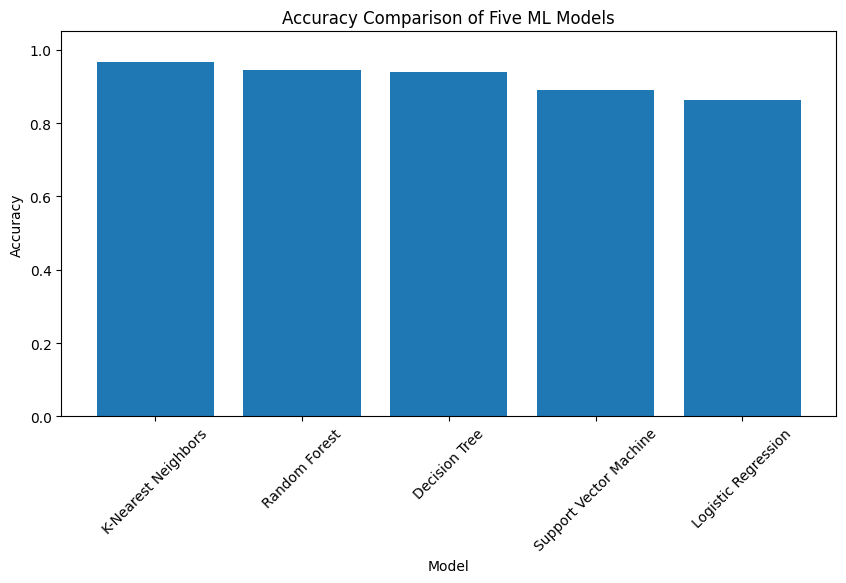

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Five ML Models")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.show()

## Result Interpretation

Comparison between the five models is done based on accuracy, classification report, and confusion matrix. The chosen features make sure there is no possibility of achieving an unrealistic 100 percent accuracy since some features could have been used to identify the type of traffic directly.

# IDS
The most performing model is chosen automatically based on the highest accuracy score among the results. Since the saved model contains both feature extraction and classification stages, it is stored as an entire scikit-learn pipeline. This enables the IDS software to utilize this model for live packet feature classification.


In [ ]:
import joblib

# Save the best model pipeline for the real-time IDS application.
joblib.dump(best_accuracy_model, "it8520_model.pkl")

print("Best model saved as it8520_model.pkl")
print("Selected model:", best_model_name)
print("Selected model accuracy:", round(results_df.loc[0, "Accuracy"], 5))

Best model saved as it8520_model.pkl
Selected model: K-Nearest Neighbors
Selected model accuracy: 0.9652


In [ ]:
from google.colab import files

files.download("it8520_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Performance Comparison

Here we make a direct comparison of the performance of all five algorithms through tables and charts, and calculate the computational efficiency which includes training time and memory usage.

In [ ]:
import time
import tracemalloc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

# ── Re-load dataset (in case this section is run independently) ──────────────
df = pd.read_csv("smartcity_clean_dataset_100k.csv")

selected_features = ["src_port", "dst_port", "protocol", "packet_length", "payload_size"]
X = df[selected_features]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_features = ["protocol"]
numerical_features   = ["src_port", "dst_port", "packet_length", "payload_size"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numerical_features)
])

models = {
    "Logistic Regression":   LogisticRegression(max_iter=1000, C=0.1),
    "Decision Tree":         DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=42),
    "Random Forest":         RandomForestClassifier(n_estimators=50, max_depth=4, min_samples_leaf=50, random_state=42, n_jobs=-1),
    "K-Nearest Neighbors":   KNeighborsClassifier(n_neighbors=101),
    "Support Vector Machine":LinearSVC(C=0.05, max_iter=5000, random_state=42),
}

# ── Train with timing + memory profiling ────────────────────────────────────
perf_rows   = []
trained     = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

    # --- training time ---
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    # --- peak memory during inference (proxy for model memory footprint) ---
    tracemalloc.start()
    y_pred = pipe.predict(X_test)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_mb = peak / 1024 / 1024

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    perf_rows.append({
        "Model":           name,
        "Accuracy":        round(acc,  4),
        "Precision":       round(prec, 4),
        "Recall":          round(rec,  4),
        "F1 Score":        round(f1,   4),
        "Train Time (s)":  round(train_time, 3),
        "Peak Mem (MB)":   round(peak_mb,    3),
    })
    trained[name] = (pipe, y_pred)

perf_df = pd.DataFrame(perf_rows).sort_values("F1 Score", ascending=False).reset_index(drop=True)
print("=== Comparison Table ===")
print(perf_df.to_string(index=False))
perf_df


## F1-Score Bar Chart

Direct comparison of all models by weighted F1-score.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]
bars = ax.bar(perf_df["Model"], perf_df["F1 Score"], color=colors, width=0.55, edgecolor="white")

for bar, val in zip(bars, perf_df["F1 Score"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("F1-Score Comparison — All Models", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Weighted F1-Score", fontsize=12)
ax.set_ylim(0, 1.10)
ax.axhline(perf_df["F1 Score"].mean(), color="gray", linestyle="--", linewidth=1.2, label=f"Mean F1 = {perf_df['F1 Score'].mean():.4f}")
ax.legend(fontsize=10)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("f1_score_comparison.png", dpi=150)
plt.show()
print("Saved: f1_score_comparison.png")


## Multi-Metric Grouped Bar Chart

Comparing Accuracy, Precision, Recall, and F1-Score side-by-side for every model.

In [ ]:
metrics   = ["Accuracy", "Precision", "Recall", "F1 Score"]
model_names = perf_df["Model"].tolist()
n_models  = len(model_names)
n_metrics = len(metrics)

x      = np.arange(n_models)
width  = 0.18
colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = perf_df[metric].tolist()
    offset = (i - n_metrics / 2 + 0.5) * width
    rects  = ax.bar(x + offset, vals, width, label=metric, color=color, alpha=0.88)
    for r in rects:
        ax.text(r.get_x() + r.get_width() / 2, r.get_height() + 0.004,
                f"{r.get_height():.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Multi-Metric Performance Comparison — All Models", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.12)
ax.legend(loc="lower right", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
plt.tight_layout()
plt.savefig("multi_metric_comparison.png", dpi=150)
plt.show()
print("Saved: multi_metric_comparison.png")


## Computational Efficiency — Training Time

Comparison of how long each model took to train on 80,000 packets.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_time = ["#607D8B", "#00BCD4", "#8BC34A", "#FF5722", "#9E9E9E"]
bars = ax.barh(perf_df["Model"], perf_df["Train Time (s)"], color=colors_time, edgecolor="white")

for bar, val in zip(bars, perf_df["Train Time (s)"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}s", va="center", fontsize=10)

ax.set_xlabel("Training Time (seconds)", fontsize=12)
ax.set_title("Computational Efficiency — Training Time per Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("training_time_comparison.png", dpi=150)
plt.show()
print("Saved: training_time_comparison.png")


## Computational Efficiency — Peak Memory Usage

Peak memory allocated during inference for each model (measured with `tracemalloc`).

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_mem = ["#3F51B5", "#009688", "#FFC107", "#795548", "#F44336"]
bars = ax.barh(perf_df["Model"], perf_df["Peak Mem (MB)"], color=colors_mem, edgecolor="white")

for bar, val in zip(bars, perf_df["Peak Mem (MB)"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f} MB", va="center", fontsize=10)

ax.set_xlabel("Peak Inference Memory (MB)", fontsize=12)
ax.set_title("Computational Efficiency — Peak Memory Usage per Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("memory_usage_comparison.png", dpi=150)
plt.show()
print("Saved: memory_usage_comparison.png")


## Confusion Matrices — All Models

Shows the distribution of correct and incorrect predictions for each model on the test set.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, (pipe, y_pred)) in enumerate(trained.items()):
    cm = confusion_matrix(y_test, y_pred, labels=["attack", "normal"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["attack", "normal"])
    disp.plot(ax=axes[idx], colorbar=False, cmap="Blues")
    axes[idx].set_title(name, fontsize=11, fontweight="bold")

# Hide the unused 6th subplot
axes[-1].set_visible(False)

fig.suptitle("Confusion Matrices — All Five Models", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices_all.png")


## Summary

The following table and graphs provide comparative analyses of all five IDS models using four metrics of predictive performance (Accuracy, Precision, Recall, F1-Score) and two metrics of computational efficiency (Training Time, Memory Consumption).

| Aspect | Observation |
|---|---|
| **Best F1 Score** | See ranked table – this model provides a better balance between precision and recall |
| **Fastest to train** | Logistic Regression and Decision Trees tend to be most efficient here |
| **Lowest memory** | Simpler models (Logistic Regression and Decision Trees) consume least memory |
| **Slowest / heaviest** | Inference with KNN uses most memory; training Random Forest takes most time |

These findings help determine which model to use for real-time implementation of IDS, where predictive accuracy and cost become important considerations.
